# GreenAid Multimodal Data Loading

This notebook demonstrates how to load and visualize the GreenAid multimodal dataset. The dataset contains three types of imagery for each sample:
- **RGB**: 3-channel true color images (64x64 pixels).
- **Multispectral (MS)**: 5-channel images capturing specific wavelengths (NIR, Red, Green, Blue, Red-edge) at 64x64 pixels.
- **Hyperspectral (HS)**: 125-channel data cubes at 32x32 pixels, providing a detailed spectral profile.

## 1. Setup and Imports

We use `tifffile` for multispectral and hyperspectral TIFFs, and `PIL` for standard PNG images.

In [1]:
import os
import glob
import numpy as np
import tifffile
from PIL import Image
import matplotlib.pyplot as plt

# Corrected Paths relative to the root directory where the notebook is saved
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data', 'train')
print(f"Searching for data in: {DATA_DIR}")

MODALITIES = ['RGB', 'MS', 'HS']

Searching for data in: /home/jyoti/Documents/COMPITION/Kaggle/GreenAid/data/train


## 2. Data Loading Functions

The samples are aligned by their IDs. We extract these IDs from the filenames and create a helper to load all three modalities for a single sample.

In [2]:
def get_sample_ids(data_dir):
    """Extract sample IDs from RGB filenames."""
    rgb_path = os.path.join(data_dir, 'RGB', '*.png')
    rgb_files = glob.glob(rgb_path)
    if not rgb_files:
        print(f"Warning: No files found at {rgb_path}")
        return []
    return sorted([os.path.splitext(os.path.basename(f))[0] for f in rgb_files])

def load_multimodal_sample(data_dir, sample_id):
    """Load all modalities for a given sample ID."""
    sample = {}
    
    # RGB (.png)
    rgb_img_path = os.path.join(data_dir, 'RGB', f"{sample_id}.png")
    if os.path.exists(rgb_img_path):
        sample['RGB'] = np.array(Image.open(rgb_img_path))
    
    # MS and HS (.tif)
    for mod in ['MS', 'HS']:
        path = os.path.join(data_dir, mod, f"{sample_id}.tif")
        if os.path.exists(path):
            sample[mod] = tifffile.imread(path)
            
    return sample

ids = get_sample_ids(DATA_DIR)
print(f"Found {len(ids)} samples.")

Found 600 samples.


## 3. Basic Visualization

A quick look at the raw data. Since MS and HS have many channels, we visualize the first 3 bands and perform simple normalization.

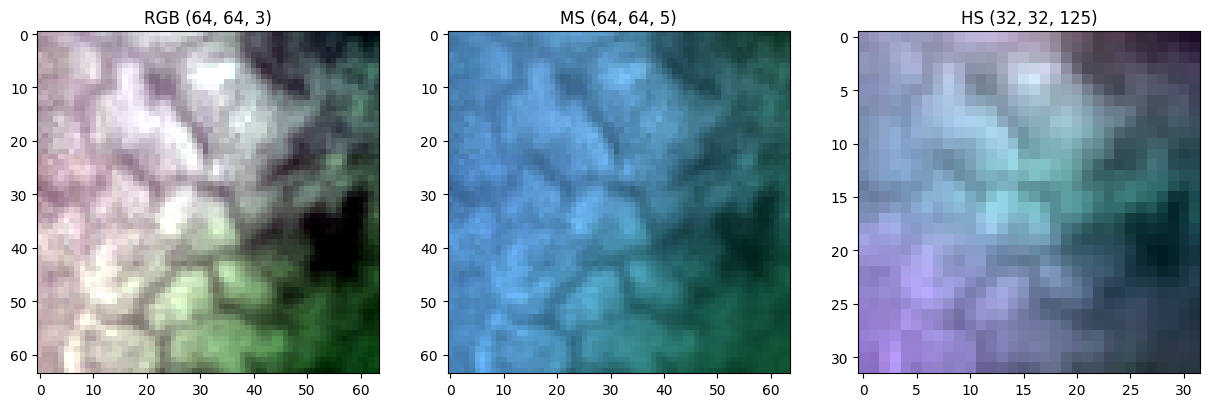

In [3]:
if ids:
    # Load and display first sample
    sample_0 = load_multimodal_sample(DATA_DIR, ids[0])

    plt.figure(figsize=(15, 5))
    for i, mod in enumerate(['RGB', 'MS', 'HS']):
        if mod in sample_0:
            plt.subplot(1, 3, i+1)
            data = sample_0[mod]
            
            # For visualization: pick 3 bands if multi-channel
            if data.ndim == 3:
                # Handle (H, W, C) format
                viz = data[..., :3].copy()
            else:
                viz = data
            
            # Normalize for visualization if not standard uint8
            if viz.dtype != np.uint8:
                v_min, v_max = viz.min(), viz.max()
                if v_max > v_min:
                    viz = (viz - v_min) / (v_max - v_min)
            
            plt.imshow(viz)
            plt.title(f"{mod} {data.shape}")
    plt.show()
else:
    print("No samples to display. Please verify the DATA_DIR path.")

## 4. Advanced Visualization

To better analyze crop health, we can use specific band combinations:
- **MS False Color**: Using NIR-Red-Green bands (Indices 4, 2, 1) to highlight vegetation health.
- **HS Spectral Profile**: Plotting the mean reflectance across all 125 bands to see the "spectral signature" of the plant.

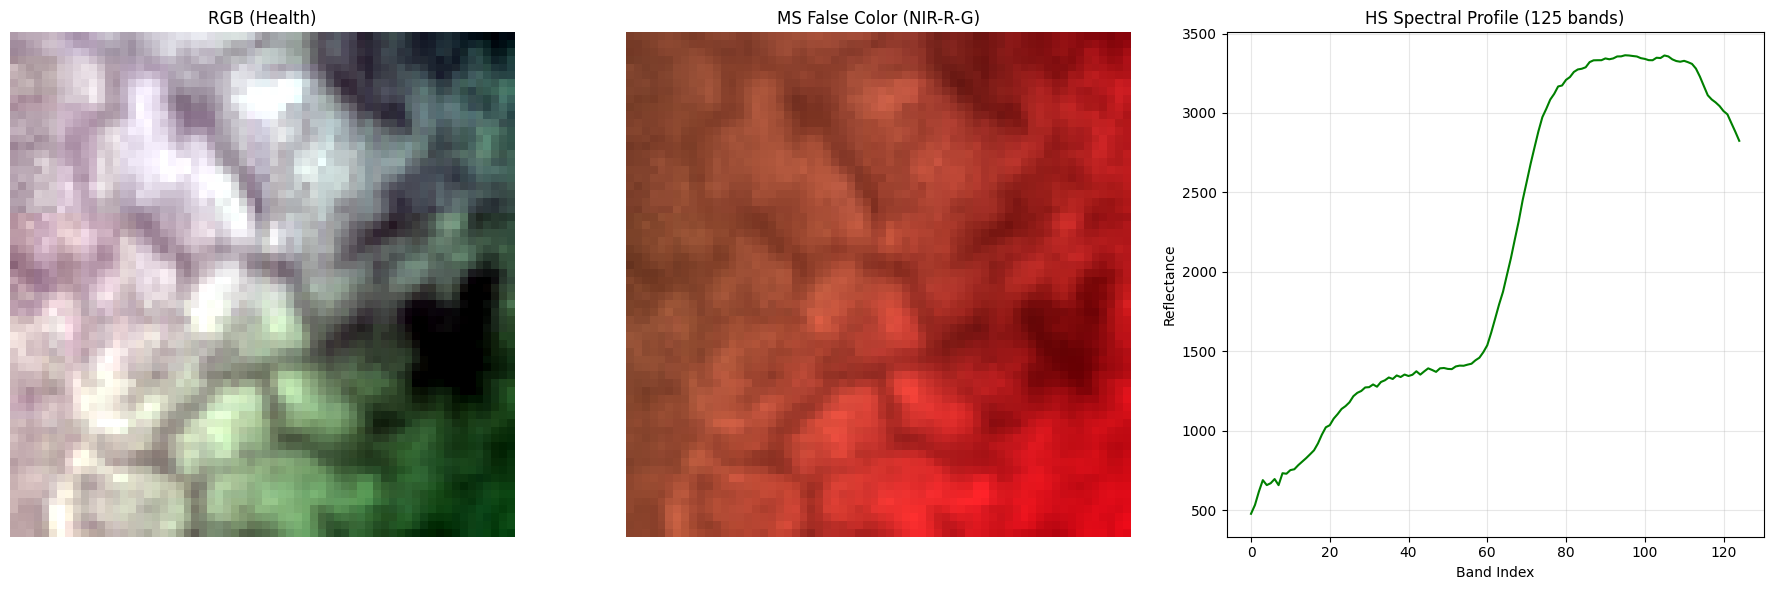

In [4]:
import matplotlib.pyplot as plt

def visualize_advanced(sample, label_name):
    plt.figure(figsize=(18, 6))
    
    # 1. RGB Standard
    plt.subplot(1, 3, 1)
    plt.imshow(sample['RGB'])
    plt.title(f"RGB ({label_name})")
    plt.axis('off')
    
    # 2. MS False Color (NIR, Red, Green) -> Indices [4, 2, 1]
    # This highlight vegetation health
    if 'MS' in sample:
        plt.subplot(1, 3, 2)
        ms = sample['MS'].astype(float)
        # Using [NIR, Red, Green] for standard False Color
        false_color = ms[..., [4, 2, 1]] 
        false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min())
        plt.imshow(false_color)
        plt.title("MS False Color (NIR-R-G)")
        plt.axis('off')

    # 3. HS Spectral Signature
    # Plotting the mean intensity across all 125 bands
    if 'HS' in sample:
        plt.subplot(1, 3, 3)
        hs = sample['HS'] # (H, W, 125)
        avg_profile = hs.mean(axis=(0,1))
        plt.plot(avg_profile, color='green' if label_name == 'Health' else 'orange')
        plt.title(f"HS Spectral Profile (125 bands)")
        plt.xlabel("Band Index")
        plt.ylabel("Reflectance")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run it on our sample
label_map = {0: 'Health', 1: 'Rust', 2: 'Other'}
# Note: sample_0 and ids[0] come from previous cells
visualize_advanced(sample_0, ids[0].split('_')[0]) 